# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import random
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_predict, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, QuantileTransformer, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor, RANSACRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from pygam import LinearGAM, s
from scipy.stats import randint, uniform
import scipy.sparse
import warnings
warnings.filterwarnings("ignore")

# 2. Load and Preprocess Data

In [4]:
df = pd.read_csv("data/movie_data_encoded.csv")

def handle_outliers(df, columns, method='cap'):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.05)
        Q3 = df_clean[col].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR
        if method == 'cap':
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)
    return df_clean

def plot_residual_diagnostics(y_true, y_pred):
    residuals = y_true - y_pred
    standardized_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs[0, 0].scatter(y_pred, residuals, alpha=0.6)
    axs[0, 0].axhline(0, color='red', linestyle='--')
    axs[0, 0].set_title('Residuals vs Fitted')
    axs[0, 0].set_xlabel('Fitted Values')
    axs[0, 0].set_ylabel('Residuals')
    stats.probplot(residuals, dist="norm", plot=axs[0, 1])
    axs[0, 1].set_title('Normal Q-Q Plot')
    sns.histplot(residuals, bins=30, kde=True, ax=axs[1, 0])
    axs[1, 0].set_title('Histogram of Residuals')
    axs[1, 1].plot(residuals, marker='o', linestyle='', alpha=0.6)
    axs[1, 1].axhline(0, color='red', linestyle='--')
    axs[1, 1].set_title('Residuals vs Observation Order')
    axs[1, 1].set_xlabel('Observation Order')
    axs[1, 1].set_ylabel('Residual')
    plt.tight_layout()
    plt.show()

def error_analysis(y_true, y_pred, X_data):
    residuals = y_true - y_pred
    error_df = X_data.assign(
        true_revenue=y_true / 1e6,
        pred_revenue=y_pred / 1e6,
        residual=residuals / 1e6,
        pct_error=residuals / y_true
    )
    print("Top 5 Underestimations:")
    display(error_df.nlargest(5, 'residual'))
    print("\nTop 5 Overestimations:")
    display(error_df.nsmallest(5, 'residual'))
    return error_df

def check_revenue_distribution(series):
    plt.figure(figsize=(8,5))
    sns.histplot(series, bins=50, kde=True)
    plt.title("Revenue Distribution")
    plt.show()

# Initial data cleaning
df_clean = df[(df['trailer_views'] >= 0) & (df['trailer_likes'] >= 0)].copy()
df_clean = df_clean.dropna(subset=['release_date', 'budget', 'actor_score'])  # Avoid null values
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean = handle_outliers(df_clean, df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist())

# Feature engineering
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['release_year_centered'] = df_clean['release_year'] - df_clean['release_year'].mean()
df_sorted_asc = df_clean.sort_values(by='release_date')

# Select important features based on domain expertise
important_feature_based_on_domain_expertise = ['budget', 'actor_score', 'star_score', 'trailer_views', 'trailer_likes', 'revenue', 'release_year', 'release_year_centered']
test = df_sorted_asc[important_feature_based_on_domain_expertise].copy()

# Transform features
test['revenue'] = np.log1p(test['revenue'])
test['trailer_likes_log'] = np.log1p(test['trailer_likes'])
test['trailer_views_log'] = np.log1p(test['trailer_views'])
test['budget_log'] = np.log1p(test['budget'])
test['actor_score_log'] = np.log1p(test['actor_score'])
test['budget_actor_interaction'] = test['budget_log'] * test['actor_score_log']

test = test[['trailer_views_log', 'trailer_likes_log', 'budget_log', 'budget_actor_interaction',
              'release_year_centered', 'revenue']]

# Check revenue distribution
print("Revenue statistics (in millions):")
print(df_clean['revenue'].describe() / 1e6)

Revenue statistics (in millions):
count      0.010487
mean      26.947862
std       39.910006
min        0.000001
25%        2.330829
50%       13.464154
75%       35.085382
max      294.717694
Name: revenue, dtype: float64


# 3. Exploratory Data Analysis

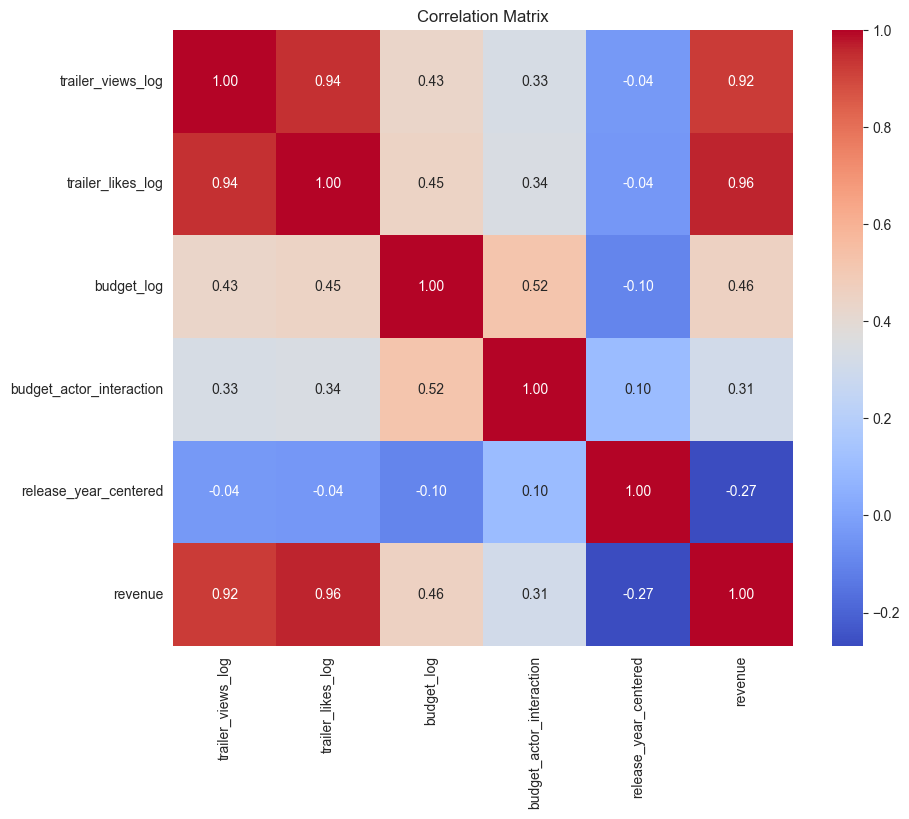

Baseline Model - RMSE: 28.15 Millions, R²: -0.3883


In [5]:
# Calculate correlation matrix
corr_matrix = test.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Prepare data for modeling
X = test.drop('revenue', axis=1)
y = df_sorted_asc['revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
y_train_log = np.log1p(y_train)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create polynomial features for more complex models
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
feature_names = poly.get_feature_names_out(X.columns)

# Scale polynomial features
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# Baseline model (mean prediction)
dummy_pred = np.full_like(y_test, y_train.mean())
RMSE_dummy = np.sqrt(mean_squared_error(y_test, dummy_pred)) / 1e6
R2_dummy = r2_score(y_test, dummy_pred)
print(f"Baseline Model - RMSE: {RMSE_dummy:.2f} Millions, R²: {R2_dummy:.4f}")


# 4. Linear Models

## 4.1 Linear Regression


Cross-validated RMSE: 19.43 Millions
Cross-validated R-squared: 0.79
RMSE: 9.01 Millions
R-squared: 0.86


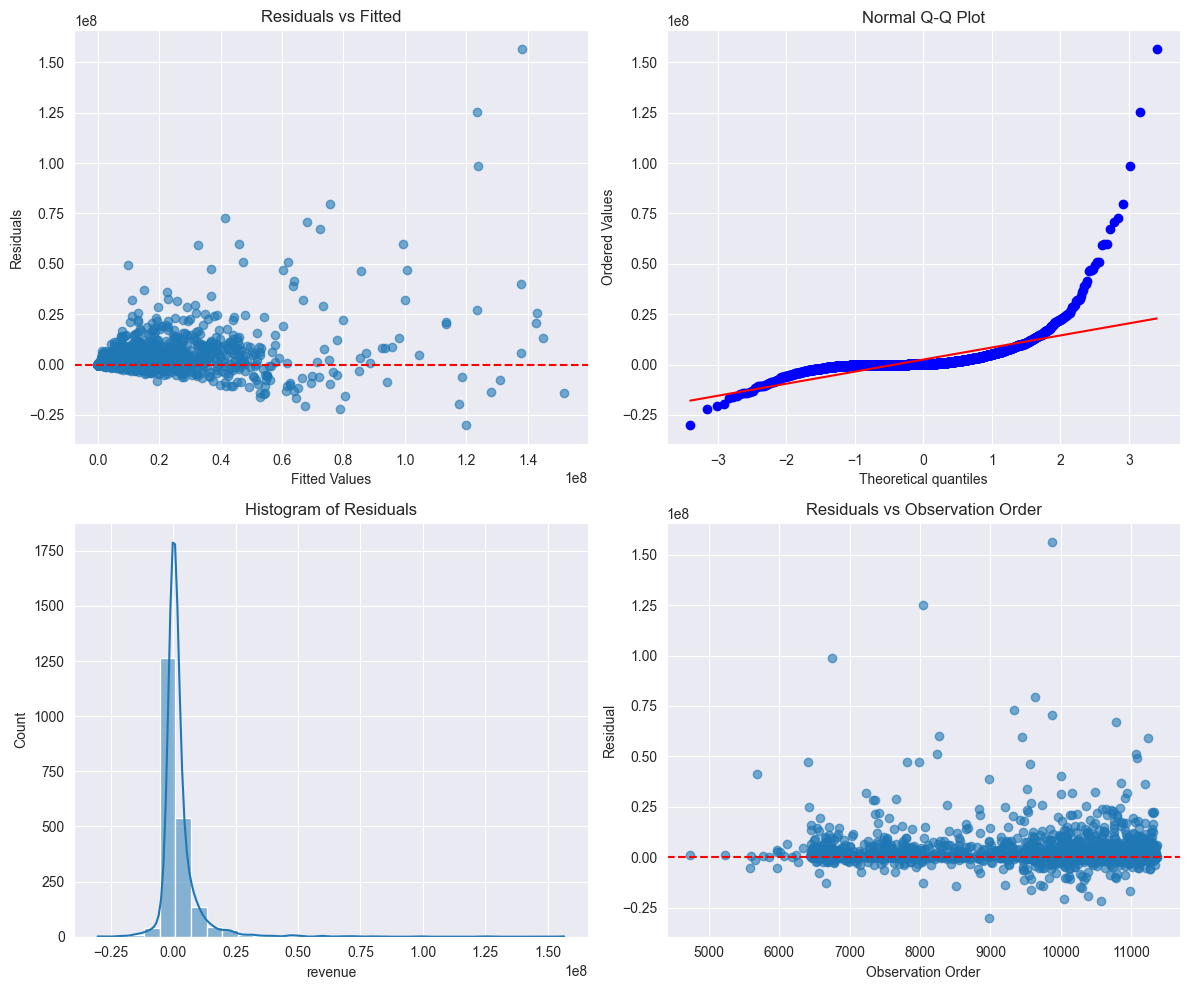

In [4]:
model = LinearRegression()
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_log_cv = cross_val_predict(model, X_train, y_train_log, cv=cv)
y_pred_cv = np.expm1(y_pred_log_cv)
y_true_cv = np.expm1(y_train_log)
rmse_cv = np.sqrt(mean_squared_error(y_true_cv, y_pred_cv)) / 1e6
r2_cv = r2_score(y_true_cv, y_pred_cv)
print(f"Cross-validated RMSE: {round(rmse_cv, 2)} Millions")
print(f"Cross-validated R-squared: {round(r2_cv, 2)}")

model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")
plot_residual_diagnostics(y_test, y_pred)

## 4.2 ElasticNet Regression


In [5]:
EL_tune = ElasticNet()
search_space = {
    'alpha': np.logspace(-4, 2, 50),
    'l1_ratio': np.linspace(0, 1, 21)
}
grid_search = GridSearchCV(estimator=EL_tune, param_grid=search_space, cv=KFold(n_splits=5), scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train_log)
model = ElasticNet(alpha=np.float64(0.00030888435964774815), l1_ratio=np.float64(0.95), random_state=42)
model.fit(X_train, y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")

grid_search.fit(X_train, y_train_log)


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.927e+02, tolerance: 4.602e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.070e+02, tolerance: 4.548e+00 Linear regression models with null weight for the l1 regularization term are more ef

RMSE: 9.01 Millions
R-squared: 0.86


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.070e+02, tolerance: 4.548e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.153e+02, tolerance: 4.425e+00 Linear regression models with null weight for the l1 regularization term are more ef

GridSearchCV(cv=KFold(n_splits=5, random_state=None, shuffle=False),
             estimator=ElasticNet(), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-04, 1.32571137e-04, 1.75751062e-04, 2.32995181e-04,
       3.08884360e-04, 4.09491506e-04, 5.42867544e-04, 7.19685673e-04,
       9.54095476e-04, 1.26485522e-03, 1.67683294e-03, 2.22299648e-03,
       2.94705170e-03, 3.90693994e-03, 5.17947468e-03...
       2.55954792e+00, 3.39322177e+00, 4.49843267e+00, 5.96362332e+00,
       7.90604321e+00, 1.04811313e+01, 1.38949549e+01, 1.84206997e+01,
       2.44205309e+01, 3.23745754e+01, 4.29193426e+01, 5.68986603e+01,
       7.54312006e+01, 1.00000000e+02]),
                         'l1_ratio': array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])},
             scoring='neg_mean_squared_error')

## 4.3 Generalized Additive Model (GAM)


RMSE: 8.06 Millions
R-squared: 0.89


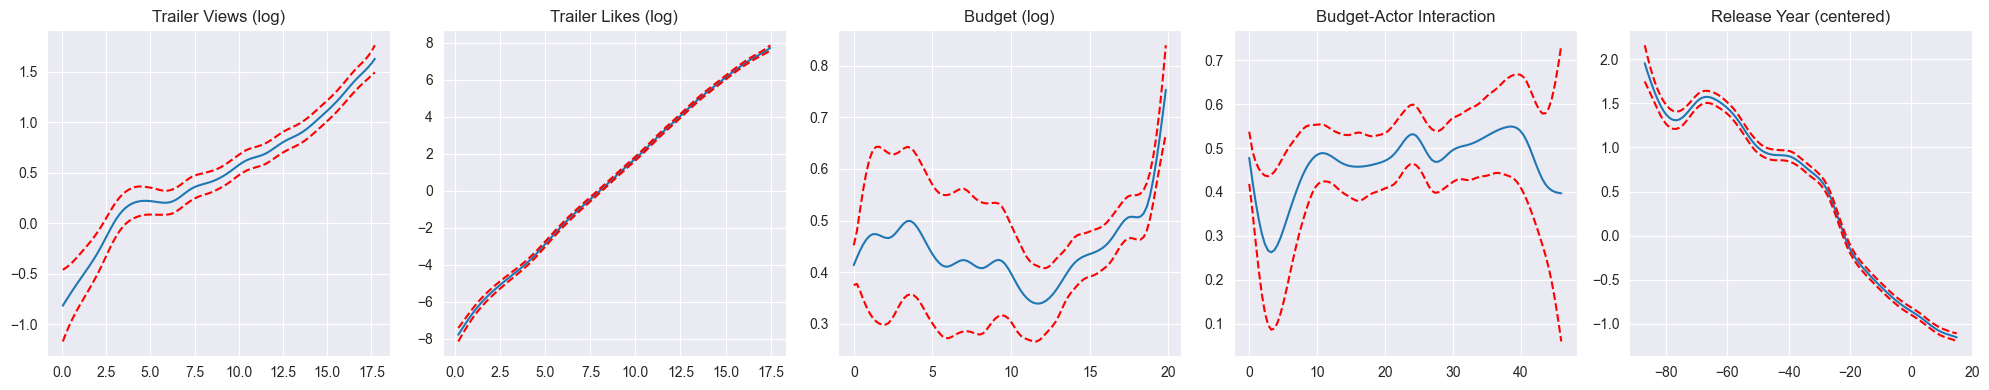

In [6]:

np.int = int
scipy.sparse.csr_matrix.A = property(lambda self: self.toarray())
gam = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4)).fit(X_train, y_train_log)
y_pred_log = gam.predict(X_test)
y_pred = np.expm1(y_pred_log)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) / 1e6
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {round(rmse, 2)} Millions")
print(f"R-squared: {round(r2, 2)}")

scipy.sparse.csc_matrix.A = property(lambda self: self.toarray())
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
titles = ["Trailer Views (log)", "Trailer Likes (log)", "Budget (log)", "Budget-Actor Interaction", "Release Year (centered)"]
for i, ax in enumerate(axs):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=0.95)[1], c='r', ls='--')
    ax.set_title(titles[i])
plt.tight_layout()
plt.show()


# 5. Non-linear Model

## 5.1 Random Forest Regressor


Best RF parameters: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 761}
Random Forest - RMSE: 8.34 Millions, R²: 0.8781


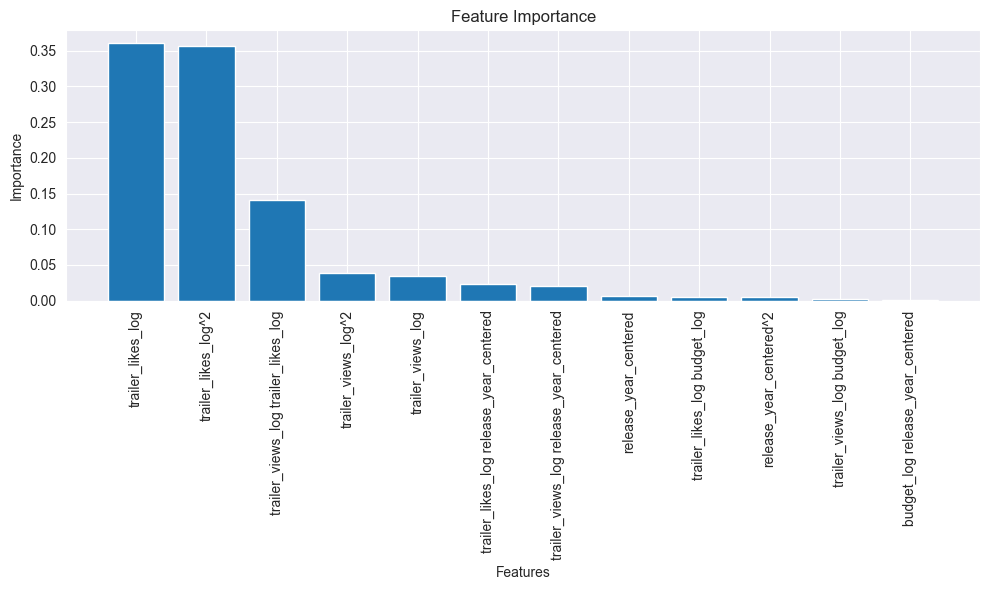

In [7]:
RFR_tune = RandomForestRegressor(random_state=42)
param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5, None]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rand_search = RandomizedSearchCV(RFR_tune, param_distributions=param_dist,
                               n_iter=10, cv=kf, scoring='neg_mean_squared_error',
                               random_state=42, n_jobs=-1)
rand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())
print(f"Best RF parameters: {rand_search.best_params_}")

Best_RFR = rand_search.best_estimator_
y_pred_rf_log = Best_RFR.predict(X_test_poly_scaled)
y_pred_rf = np.expm1(y_pred_rf_log)
RMSE_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf)) / 1e6
R2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - RMSE: {RMSE_rf:.2f} Millions, R²: {R2_rf:.4f}")

# Feature importance
importances = Best_RFR.feature_importances_
feature_importances = pd.DataFrame(importances, index=feature_names,
                                 columns=["importance"]).sort_values("importance", ascending=False)

# Select important features (importance >= 0.001)
important_features = feature_importances[feature_importances["importance"] >= 0.001].index

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
important_importance_values = feature_importances.loc[important_features, "importance"]
plt.bar(range(len(important_features)), important_importance_values, align="center")
plt.xticks(range(len(important_features)), important_features, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# Map feature names to column indices for reduced feature set
important_feature_indices = [i for i, name in enumerate(feature_names) if name in important_features]
X_train_poly_important = X_train_poly_scaled[:, important_feature_indices]
X_test_poly_important = X_test_poly_scaled[:, important_feature_indices]


## 5.2 Gradient Boosting Regressor

In [8]:
GDB = GradientBoostingRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=2,
                              min_samples_split=10, n_estimators=200, subsample=0.8,
                              random_state=42)
GDB.fit(X_train_poly_important, y_train_log.values.ravel())
y_pred_gdb_log = GDB.predict(X_test_poly_important)
y_pred_gdb = np.expm1(y_pred_gdb_log)
RMSE_gdb = np.sqrt(mean_squared_error(y_test, y_pred_gdb)) / 1e6
R2_gdb = r2_score(y_test, y_pred_gdb)
print(f"Gradient Boosting - RMSE: {RMSE_gdb:.2f} Millions, R²: {R2_gdb:.4f}")


Gradient Boosting - RMSE: 7.85 Millions, R²: 0.8920


## 5.3  XGBoost with Time-Based Split


In [ ]:
import gc
gc.collect()

# Use the original dataframe for this approach
df_for_time_split = df.copy()

# Ensure we have a release_year column
if "release_date" not in df_for_time_split.columns:
    print("release_date column not found in the original dataset.")
else:
    # Convert to datetime and extract year if not already done
    df_for_time_split["release_date"] = pd.to_datetime(df_for_time_split["release_date"], errors="coerce")
    df_for_time_split["release_year"] = df_for_time_split["release_date"].dt.year

    # Define columns to drop for feature selection
    drop_cols = [
        "Unnamed: 0", "name", "genres", "directors", "writers",
        "actors", "original_language", "production_companies",
        "release_date", "keywords", "revenue"  # we keep 'release_year'!
    ]

    # Create feature matrix and target
    y_time = df_for_time_split["revenue"]
    X_time = df_for_time_split.drop(columns=drop_cols, errors="ignore")

    print(f"Data shape for time-based split - X: {X_time.shape}, y: {y_time.shape}")

    # Perform time-based split
    all_years = sorted(X_time["release_year"].dropna().unique())
    boundary_year = 2015  # Choose a reasonable boundary
    train_years = [year for year in all_years if year < boundary_year]
    test_years = [year for year in all_years if year >= boundary_year]

    print(f"Time-based splitting by release_year...")
    print("Train years:", train_years)
    print("Test years:", test_years)

    # Build masks for splitting
    train_mask = X_time["release_year"].isin(train_years)
    test_mask = X_time["release_year"].isin(test_years)

    # Split data
    X_train_time = X_time[train_mask].copy()
    X_test_time = X_time[test_mask].copy()
    y_train_time = y_time[train_mask]
    y_test_time = y_time[test_mask]

    # Verify split
    overlap = set(X_train_time["release_year"].unique()).intersection(X_test_time["release_year"].unique())
    if overlap:
        print("WARNING: Overlap in train/test years:", overlap)
    else:
        print("No overlap in train/test years (good).")

    print(f"X_train_time shape: {X_train_time.shape}, X_test_time shape: {X_test_time.shape}")

    # Preprocessing - select only numeric columns
    numeric_cols = X_train_time.select_dtypes(include=[np.number]).columns
    X_train_time_numeric = X_train_time[numeric_cols].fillna(0)
    X_test_time_numeric = X_test_time[numeric_cols].fillna(0)

    # Scale the features
    scaler_time = StandardScaler()
    X_train_time_scaled = scaler_time.fit_transform(X_train_time_numeric)
    X_test_time_scaled = scaler_time.transform(X_test_time_numeric)

    # Train the model
    xgb_time = XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1
    )

    xgb_time.fit(X_train_time_scaled, y_train_time)

    # Make predictions
    y_pred_time = xgb_time.predict(X_test_time_scaled)

    # Evaluate
    rmse_time = np.sqrt(mean_squared_error(y_test_time, y_pred_time)) / 1e6
    r2_time = r2_score(y_test_time, y_pred_time)

    print("\n=== PERFORMANCE METRICS (Time-based Split) ===")
    print(f"Test RMSE: {rmse_time:.2f} Millions")
    print(f"Test R²: {r2_time:.4f}")

    # Quick scatter plot
    plt.figure(figsize=(8,6))
    plt.scatter(y_test_time / 1e6, y_pred_time / 1e6, alpha=0.5)
    plt.plot([y_test_time.min() / 1e6, y_test_time.max() / 1e6],
             [y_test_time.min() / 1e6, y_test_time.max() / 1e6], 'r--')
    plt.xlabel("True Revenue (Millions)")
    plt.ylabel("Predicted Revenue (Millions)")
    plt.title("Time-based Split: Actual vs. Predicted Revenue")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot feature importance
    feature_importance = pd.DataFrame({
        'Feature': numeric_cols,
        'Importance': xgb_time.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
    plt.title('XGBoost Feature Importance (Time-based Split)')
    plt.tight_layout()
    plt.show()

## 5.4 Muti-Layer Perceptron

Important features not previously defined. Using all polynomial features.
Neural network architecture: Input(20) → Hidden([64, 32]) → Output(1)

Training Fold 1/5
Epoch [100/10000], Train Loss: 2.9300, Val Loss: 0.2118
Epoch [200/10000], Train Loss: 2.0850, Val Loss: 0.1473
Epoch [300/10000], Train Loss: 1.6670, Val Loss: 0.1364
Epoch [400/10000], Train Loss: 1.4588, Val Loss: 0.1203
Epoch [500/10000], Train Loss: 1.3064, Val Loss: 0.1082
Epoch [600/10000], Train Loss: 1.1344, Val Loss: 0.1054
Epoch [700/10000], Train Loss: 1.0162, Val Loss: 0.1106
Epoch [800/10000], Train Loss: 0.9286, Val Loss: 0.0950
Epoch [900/10000], Train Loss: 0.8203, Val Loss: 0.0971
Epoch [1000/10000], Train Loss: 0.7188, Val Loss: 0.1104
Epoch [1100/10000], Train Loss: 0.6915, Val Loss: 0.0884
Epoch [1200/10000], Train Loss: 0.6874, Val Loss: 0.0885
Epoch [1300/10000], Train Loss: 0.6882, Val Loss: 0.0925
Epoch [1400/10000], Train Loss: 0.6665, Val Loss: 0.0892
Epoch [1500/10000], Train Loss: 0.6292, Val Loss

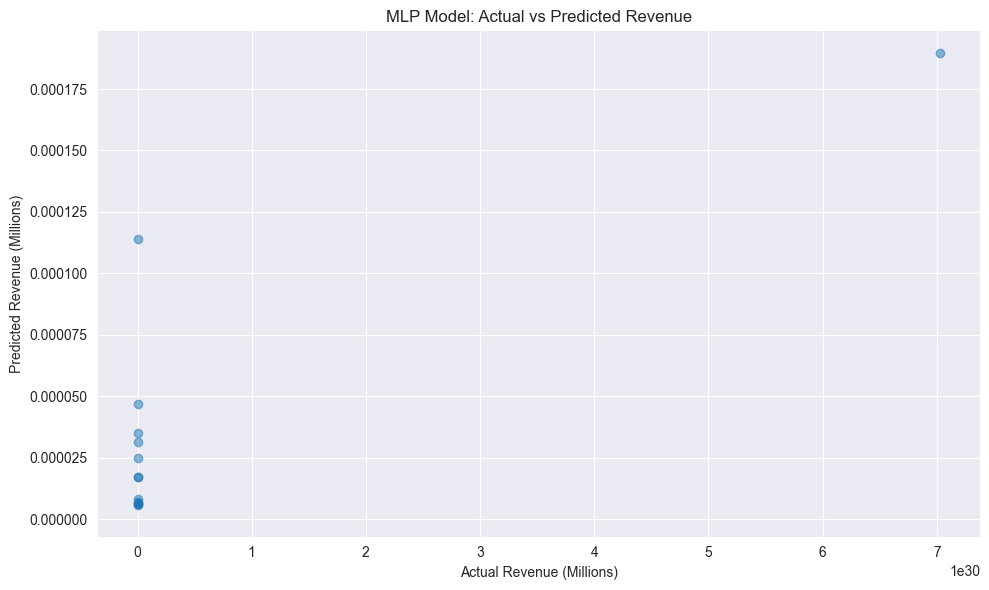

In [9]:
def set_seed(seed=42):
    """Set random seeds for reproducibility across all libraries"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)  # Set random seed for reproducibility

class MLP(nn.Module):
    """Multi-layer perceptron with batch normalization and dropout"""
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.2):
        super(MLP, self).__init__()
        layers = []
        last_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(last_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # Stabilize training
            layers.append(nn.ELU(alpha=1.0))      # Activation function
            layers.append(nn.Dropout(dropout))    # Regularization
            last_dim = h_dim
        layers.append(nn.Linear(last_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

def create_model(input_dim, hidden_dims, output_dim):
    """Factory function to create MLP model with given architecture"""
    model = MLP(input_dim, hidden_dims, output_dim)
    return model

# Check if the important feature data is available
# If not, create it from the original polynomial features
if 'important_feature_indices' not in locals() or 'X_train_poly_important' not in locals():
    print("Important features not previously defined. Using all polynomial features.")
    X_train_poly_important = X_train_poly_scaled
    X_test_poly_important = X_test_poly_scaled
else:
    print(f"Using {len(important_feature_indices)} important features selected by Random Forest.")

# Define model architecture
input_dim = X_train_poly_important.shape[1]  # Number of input features
hidden_dims = [64, 32]  # Two hidden layers with 64 and 32 neurons
output_dim = 1  # Regression output (single value prediction)

print(f"Neural network architecture: Input({input_dim}) → Hidden({hidden_dims}) → Output({output_dim})")

# Convert data to PyTorch tensors
X_tensor = torch.tensor(X_train_poly_important, dtype=torch.float)
y_tensor = torch.tensor(y_train_log.values, dtype=torch.float).view(-1, 1)

# Set up k-fold cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_performances = []

# Early stopping parameters
num_epochs = 10000
patience = 1000  # Stop if no improvement for `patience` epochs

for fold, (train_index, val_index) in enumerate(kf.split(X_tensor)):
    print(f"\nTraining Fold {fold+1}/{k}")

    # Split data for this fold
    X_train_cv = X_tensor[train_index]
    y_train_cv = y_tensor[train_index]
    X_val_cv = X_tensor[val_index]
    y_val_cv = y_tensor[val_index]

    # Initialize model, optimizer and loss function
    model = create_model(input_dim, hidden_dims, output_dim)
    optimizer = optim.Adam(model.parameters(), lr=0.1, weight_decay=1e-4)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        # Dynamic learning rate schedule
        if epoch > 1000:
            for param_group in optimizer.param_groups:
                param_group["lr"] = 0.01
        elif epoch > 3000:
            for param_group in optimizer.param_groups:
                param_group["lr"] = 0.0001

        # Training phase
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_cv)
        loss = criterion(outputs, y_train_cv)
        loss.backward()
        optimizer.step()

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_cv)
            val_loss = criterion(val_outputs, y_val_cv).item()

            # Early stopping check
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch+1}, best val loss: {best_val_loss:.4f}")
                break

            # Print progress every 100 epochs
            if (epoch + 1) % 100 == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}")

    fold_performances.append(best_val_loss)

# Calculate average performance across all folds
avg_val_loss = np.mean(fold_performances)
print(f"\nAverage Validation Loss across {k} folds: {avg_val_loss:.4f}")

# Final evaluation on test set
X_test_tensor = torch.tensor(X_test_poly_important, dtype=torch.float)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float).view(-1, 1)

# Evaluation in log space
model.eval()
with torch.no_grad():
    test_outputs_log = model(X_test_tensor)
    test_loss = criterion(test_outputs_log, y_test_tensor)

    # Convert predictions back to original scale
    test_outputs = torch.expm1(test_outputs_log)
    y_test_original = torch.expm1(y_test_tensor)

    # Compute metrics in original scale
    mse = torch.mean((test_outputs - y_test_original) ** 2)
    rmse = torch.sqrt(mse) / 1e6  # Convert to millions for readability

    # Calculate R² score
    ss_res = torch.sum((y_test_original - test_outputs) ** 2)
    ss_tot = torch.sum((y_test_original - torch.mean(y_test_original)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

print(f'MLP - Test Loss (Log Scale): {test_loss.item():.4f}, RMSE: {rmse.item():.2f} Millions, R²: {r2.item():.4f}')

# Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original.numpy() / 1e6, test_outputs.numpy() / 1e6, alpha=0.5)
plt.plot([y_test_original.min() / 1e6, y_test_original.max() / 1e6],
         [y_test_original.min() / 1e6, y_test_original.max() / 1e6], 'r--')
plt.xlabel('Actual Revenue (Millions)')
plt.ylabel('Predicted Revenue (Millions)')
plt.title('MLP Model: Actual vs Predicted Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()
